In [1]:
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynauty
import torch

NUMBER_OF_GRAPHS = len(open("all_graphs.g6").readlines())
print(f"Number of graphs: {NUMBER_OF_GRAPHS}")

Number of graphs: 4985


In [2]:
graphs = nx.read_graph6("all_graphs.g6")
pynauty_graphs = []
nodes_counts = np.zeros(NUMBER_OF_GRAPHS)
for i, graph in enumerate(graphs):
    num_of_nodes = int(graph.number_of_nodes())
    nodes_counts[i] = num_of_nodes
    pynauty_graph = pynauty.Graph(num_of_nodes)
    pynauty_graph.set_adjacency_dict(dict(graph.adjacency()))
    pynauty_graphs.append((pynauty_graph, num_of_nodes, graph.edges()))

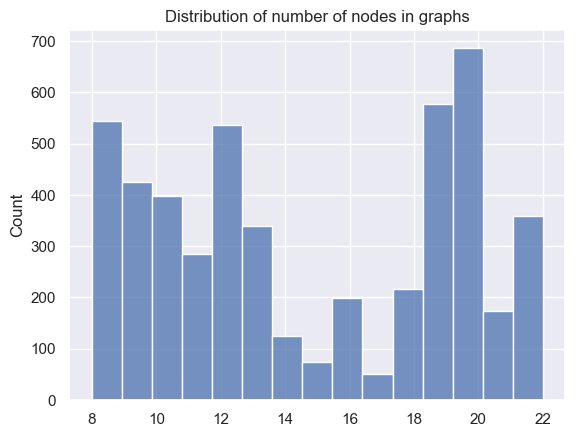

In [3]:
sns.set_theme()
sns.histplot(nodes_counts, bins=15).set(
    title="Distribution of number of nodes in graphs"
)
plt.show()

In [4]:
min_nodes = np.min(nodes_counts)
max_nodes = np.max(nodes_counts)
avg_nodes = np.mean(nodes_counts)
print(f"Min number of nodes: {min_nodes}")
print(f"Max number of nodes: {max_nodes}")
print(f"Avg number of nodes: {avg_nodes}")

Min number of nodes: 8.0
Max number of nodes: 22.0
Avg number of nodes: 14.66740220661986


In [5]:
group_sizes = np.zeros(NUMBER_OF_GRAPHS)
for i, (graph, num_of_nodes, edge_list) in enumerate(pynauty_graphs):
    generators_raw, grpsize1, grpsize2, _, _ = pynauty.autgrp(graph)
    group_size = grpsize1 * 10**grpsize2
    group_sizes[i] = group_size

In [6]:
min_group_size = np.min(group_sizes)
max_group_size = np.max(group_sizes)
avg_group_size = np.mean(group_sizes)
print(f"Min automorphism group size: {min_group_size}")
print(f"Max automorphism group size: {max_group_size}")
print(f"Avg automorphism group size: {avg_group_size}")

Min automorphism group size: 2.0
Max automorphism group size: 19200.0
Avg automorphism group size: 89.22627883650952


In [7]:
def get_stats(df, split_col="dataset_type"):
    rows = []
    for split, split_label in [("train", "Training"), ("val", "Validation")]:
        subset = df[df[split_col] == split]
        pos = subset[subset["label"] == 1].shape[0]
        neg = subset[subset["label"] == 0].shape[0]
        total = pos + neg
        ratio = f"{pos / neg:.4f}:1" if neg > 0 else "N/A"
        rows.append([split_label, total, pos, neg, ratio])
    return rows

In [15]:
larger_dataset = pd.read_csv("paut_sizes.csv")
smaller_dataset = pd.read_csv("baseline/paut_sizes_baseline.csv")
extended_features = pd.read_csv("7_features/paut_sizes_7_features.csv")


test_set = torch.load("test_dataset.pt", weights_only=False)
data = []
for graph in test_set:
    data.append((graph.num_nodes, graph.y.item()))
test_df = pd.DataFrame(data, columns=["num_nodes", "label"])

pos_test = test_df[test_df["label"] == 1].shape[0]
neg_test = test_df[test_df["label"] == 0].shape[0]
total_test = pos_test + neg_test
ratio_test = f"{pos_test / neg_test:.4f}:1" if neg_test > 0 else "N/A"

all_rows = (
    [["Baseline", *r] for r in get_stats(smaller_dataset)]
    + [["Extended Features", *r] for r in get_stats(extended_features)]
    + [["Larger", *r] for r in get_stats(larger_dataset)]
    + [["Test Set", "Test", total_test, pos_test, neg_test, ratio_test]]
)


df = pd.DataFrame(
    all_rows, columns=["Dataset", "Split", "Total", "Positive", "Negative", "Ratio"]
)
# df.to_latex("dataset_stats.tex", index=False)
df


6164


,Dataset,Split,Total,Positive,Negative,Ratio
0,Baseline,Training,48794,25891,22903,1.1305:1
1,Baseline,Validation,6109,3264,2845,1.1473:1
2,Extended Features,Training,48794,25891,22903,1.1305:1
3,Extended Features,Validation,6109,3264,2845,1.1473:1
4,Larger,Training,72950,39283,33667,1.1668:1
5,Larger,Validation,6109,3264,2845,1.1473:1
6,Test Set,Test,6164,3224,2940,1.0966:1


In [ ]:
larger_dataset["paut_relative_size"] = larger_dataset["paut_size"] / larger_dataset["num_of_nodes"]
larger_dataset.describe()

,num_of_nodes,paut_size,label,paut_relative_size
count,79059.000000,79059.000000,79059.000000,79059.000000
mean,15.174756,9.458784,0.538168,0.624390
std,4.449201,3.062448,0.498544,0.087814
min,8.000000,4.000000,0.000000,0.500000
25%,12.000000,7.000000,0.000000,0.550000
50%,15.000000,9.000000,1.000000,0.615385
75%,19.000000,12.000000,1.000000,0.687500
max,22.000000,17.000000,1.000000,0.800000


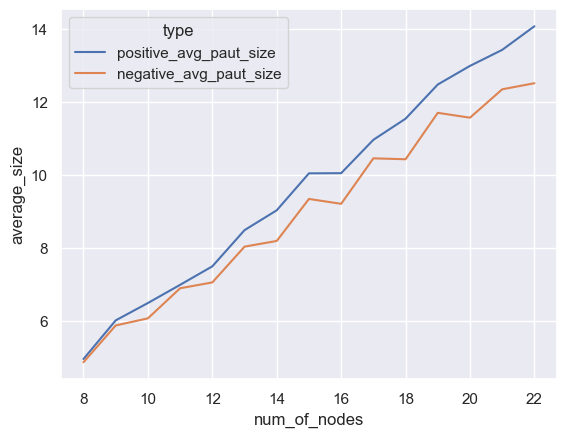

In [ ]:
positive_avg_paut_size = (
    larger_dataset[larger_dataset["label"] == 1]
    .groupby("num_of_nodes")["paut_size"]
    .mean()
    .reset_index(name="positive_avg_paut_size")
)

negative_avg_paut_size = (
    larger_dataset[larger_dataset["label"] == 0]
    .groupby("num_of_nodes")["paut_size"]
    .mean()
    .reset_index(name="negative_avg_paut_size")
)

plot_df = positive_avg_paut_size.merge(
    negative_avg_paut_size, on="num_of_nodes", how="outer"
)

plot_df = plot_df.melt(
    id_vars="num_of_nodes",
    value_vars=["positive_avg_paut_size", "negative_avg_paut_size"],
    var_name="type",
    value_name="average_size",
)

sns.lineplot(data=plot_df, x="num_of_nodes", y="average_size", hue="type")
plt.show()